Usando o exemplo 51

In [1]:
%pip install pandas numpy seaborn tensorflow
%pip install nltk
%pip install lime
%pip install imbalanced-learn
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import shap


from lime import lime_text
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Layer

# Camada de Atenção (Mover para antes da definição do modelo)
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        super(AttentionLayer, self).__init__(**kwargs)

    def build(self, input_shape):
        assert len(input_shape) == 3
        self.W = self.add_weight(name='att_W', shape=(input_shape[-1], 1), initializer='normal', trainable=True)
        self.b = self.add_weight(name='att_b', shape=(input_shape[1], 1), initializer='zeros', trainable=True)
        self.u = self.add_weight(name='att_u', shape=(input_shape[1], 1), initializer='normal', trainable=True)
        super(AttentionLayer, self).build(input_shape)

    def call(self, x):
        et = K.squeeze(K.tanh(K.dot(x, self.W) + self.b), axis=-1)
        at = K.softmax(et, axis=1)
        at = K.expand_dims(at, axis=-1)
        output = x * at
        output = K.sum(output, axis=1)
        self.attention_weights = at  # Armazenar os pesos para visualização
        return output

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])

    def get_config(self):
        config = super().get_config().copy()
        return config

c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv('../spam.csv')

In [4]:
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.shape

(5572, 2)

<Axes: xlabel='Category', ylabel='count'>

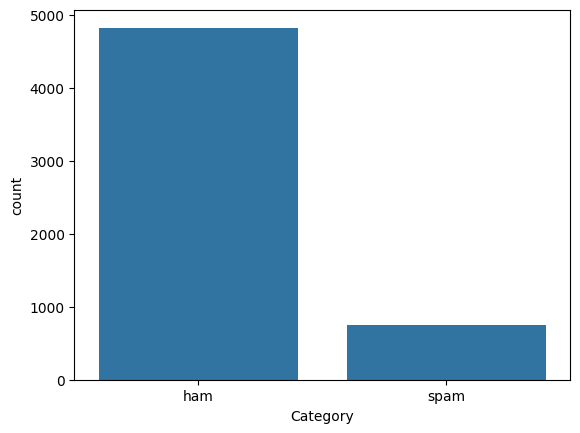

In [6]:
sns.countplot(x='Category', data=df)

**Pré-Processamento**

In [7]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

# Baixar pacotes necessários do NLTK
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download('punkt_tab') # Download the 'punkt_tab' resource

[nltk_data] Downloading package stopwords to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [8]:
def preprocess_text(text):
    # Converter para minúsculas
    text = text.lower()

    # Remover caracteres especiais e números
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenização (dividir em palavras)
    tokens = word_tokenize(text)

    # Remover stopwords
    stop_words = set(stopwords.words("english"))
    tokens = [word for word in tokens if word not in stop_words]

    # Lematização (reduzir palavras à sua forma base)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Juntar as palavras processadas de volta em uma string
    return " ".join(tokens)

In [9]:
df["clean_text"] = df["Message"].apply(preprocess_text)

In [10]:
df.head(5)

,Category,Message,clean_text
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,ham,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah dont think go usf life around though


<Axes: xlabel='Category', ylabel='count'>

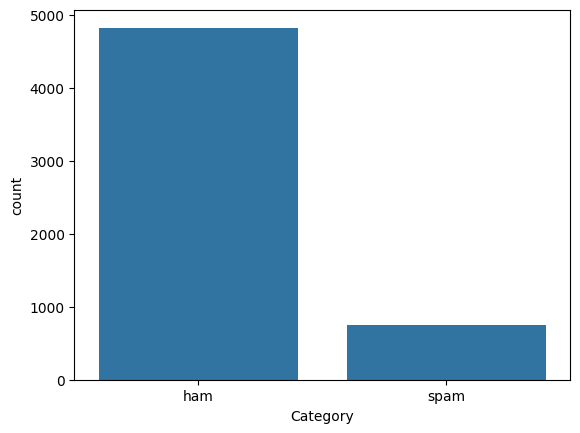

In [11]:
sns.countplot(x="Category", data=df) # validando se mudou as classes

In [12]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['Category'])

In [13]:
X = df['clean_text']
y = df['label_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#, stratify=y

In [14]:
#tokenização e padding
max_words = 5000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

**LSTM**

In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

In [16]:
# Definir o modelo LSTM
model = Sequential()
model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))
model.add(LSTM(128, return_sequences=True))  # LSTM com retorno de sequências para atenção
model.add(AttentionLayer())  # Adicionar a camada de atenção
model.add(Dense(3, activation='softmax'))  # 3 saídas para sentimentos (negativo, neutro, positivo)

c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [17]:
# Compilar o modelo
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',  # Use sparse_categorical_crossentropy se y_train for numérico
              metrics=['accuracy'])

In [18]:
# Treinar o modelo
history = model.fit(X_train_pad, y_train,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.1)  # Validação durante o treinamento

Epoch 1/10


c:\Users\LUIRYS SILVA\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\optimizers\base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['sequential/attention_layer/att_u'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


126/126 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - accuracy: 0.9013 - loss: 0.2752 - val_accuracy: 0.9372 - val_loss: 0.1910
Epoch 2/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 0.9778 - loss: 0.0747 - val_accuracy: 0.9753 - val_loss: 0.1021
Epoch 3/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.9890 - loss: 0.0412 - val_accuracy: 0.9686 - val_loss: 0.0982
Epoch 4/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 208s 1s/step - accuracy: 0.9925 - loss: 0.0294 - val_accuracy: 0.9731 - val_loss: 0.0998
Epoch 5/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9948 - loss: 0.0212 - val_accuracy: 0.9753 - val_loss: 0.1034
Epoch 6/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 183s 1s/step - accuracy: 0.9950 - loss: 0.0184 - val_accuracy: 0.9709 - val_loss: 0.1113
Epoch 7/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.9970 - loss: 0.0146 - val_accuracy: 0.9709 - val_loss: 0.1352
Epoch 8/10
126/126 ━━━━━━━━━━━━━━━━━━━━ 158s 1s/step - accuracy: 0.9973 - loss: 0.0130 - val_accuracy: 0.975

**OVERSAMPLING**

In [19]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)  # Define um estado aleatório para reprodutibilidade
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_pad, y_train)

In [20]:
# treino do modelo com os dados desbalanceados
history = model.fit(X_train_resampled, y_train_resampled,
                    epochs=10,
                    batch_size=32,
                    validation_split=0.1)

Epoch 1/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 243s 1s/step - accuracy: 0.9902 - loss: 0.0386 - val_accuracy: 0.9896 - val_loss: 0.0243
Epoch 2/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.9935 - loss: 0.0234 - val_accuracy: 0.9922 - val_loss: 0.0189
Epoch 3/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 206s 754ms/step - accuracy: 0.9951 - loss: 0.0171 - val_accuracy: 0.9922 - val_loss: 0.0188
Epoch 4/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 224s 842ms/step - accuracy: 0.9955 - loss: 0.0144 - val_accuracy: 0.9922 - val_loss: 0.0180
Epoch 5/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 193s 793ms/step - accuracy: 0.9958 - loss: 0.0144 - val_accuracy: 0.9922 - val_loss: 0.0188
Epoch 6/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 210s 819ms/step - accuracy: 0.9965 - loss: 0.0113 - val_accuracy: 0.9948 - val_loss: 0.0097
Epoch 7/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 199s 797ms/step - accuracy: 0.9964 - loss: 0.0117 - val_accuracy: 0.9948 - val_loss: 0.0109
Epoch 8/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 182s 696ms/step - accuracy: 0.9968 - loss:

<Axes: xlabel='label_encoded', ylabel='count'>

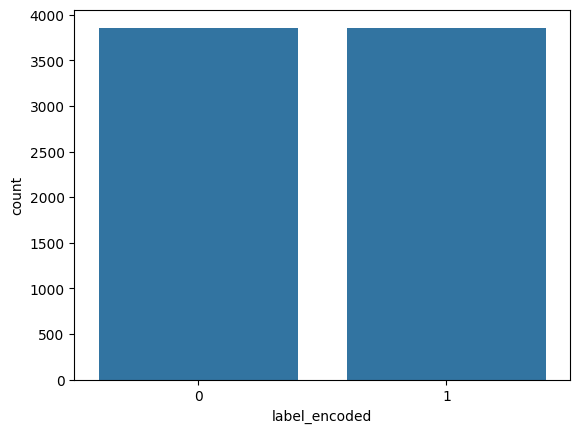

In [21]:
#verificar a nova distribuição de classes
sns.countplot(x=y_train_resampled)

**Métricas**

In [22]:
from sklearn.metrics import classification_report

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

# Gerar o relatório de classificação
print(classification_report(y_test, y_pred_classes))


35/35 ━━━━━━━━━━━━━━━━━━━━ 23s 360ms/step
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       966
           1       0.89      0.88      0.89       149

    accuracy                           0.97      1115
   macro avg       0.94      0.93      0.93      1115
weighted avg       0.97      0.97      0.97      1115



In [23]:
#acuracia,precisão, recall e f1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    return accuracy, precision, recall, f1
# Calcular as métricas
accuracy, precision, recall, f1 = calculate_metrics(y_test, y_pred_classes)
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Acurácia: 0.9695
Precisão: 0.9693
Recall: 0.9695
F1-Score: 0.9694


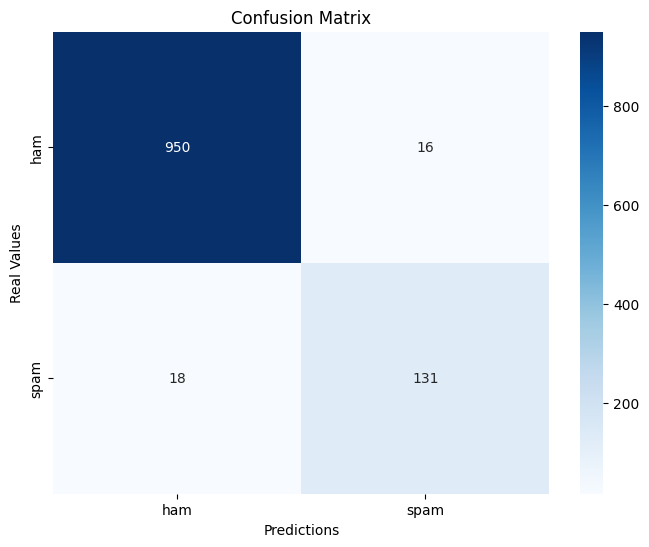

In [24]:
# Calcular a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Criar o heatmap da matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predictions")
plt.ylabel("Real Values")
plt.title("Confusion Matrix")
plt.show()

**LIME**

In [25]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=le.classes_)

def predict_proba(texts):
    sequences = tokenizer.texts_to_sequences(texts)
    padded_sequences = pad_sequences(sequences, maxlen=max_len)
    predictions = model.predict(padded_sequences)
    return predictions  # Já retorna probabilidades (softmax)

# Solicita ao usuário o número da linha do exemplo
idx = int(input(f"Digite o número da linha (0 a {len(X_test)-1}): "))
sample_text = X_test.iloc[idx]
sample_label = y_test.iloc[idx]

# Predição da classe para o texto selecionado
sample_seq = tokenizer.texts_to_sequences([sample_text])
sample_pad = pad_sequences(sample_seq, maxlen=max_len)
pred_probs = model.predict(sample_pad)
pred_class_idx = pred_probs.argmax(axis=1)[0]
pred_class_name = le.classes_[pred_class_idx]

print(f"Número da linha no X_test: {idx}")
print(f"Original text:\n{sample_text}")
print(f"Classe real: {le.classes_[sample_label]}")
print(f"Classe predita: {pred_class_name}")

explanation = explainer.explain_instance(
    sample_text,
    predict_proba,
    num_features=10
)

print(explanation.as_list())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step
Número da linha no X_test: 499
Original text:
noe shes da car later c lar im wearing short
Classe real: ham
Classe predita: ham
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 83ms/step
[(np.str_('later'), -0.003117703218836214), (np.str_('shes'), -0.0030862226111533324), (np.str_('car'), -0.0030275586631184543), (np.str_('noe'), -0.0029555947612099377), (np.str_('da'), -0.0027312633508234287), (np.str_('c'), 0.0017959985489436035), (np.str_('im'), -0.0013745910214398034), (np.str_('lar'), -0.001203097735947624), (np.str_('short'), -0.0012007833569398583), (np.str_('wearing'), -0.0011356844593290024)]


In [26]:
# Obtém as palavras mais importantes e seus pesos
lime_features = explanation.as_list()

# Exibe cada palavra com seu impacto na predição
print("Palavras mais importantes e seus pesos:")
for word, weight in lime_features:
    print(f"{word}: {weight:.4f}")

Palavras mais importantes e seus pesos:
later: -0.0031
shes: -0.0031
car: -0.0030
noe: -0.0030
da: -0.0027
c: 0.0018
im: -0.0014
lar: -0.0012
short: -0.0012
wearing: -0.0011


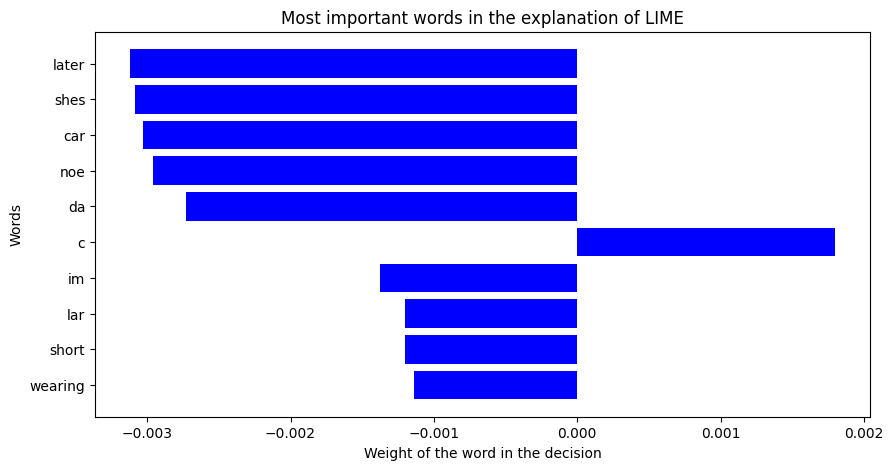

In [27]:
# Separar palavras e pesos
words, weights = zip(*lime_features)

# Criar gráfico de barras
plt.figure(figsize=(10, 5))
plt.barh(words, weights, color="blue")
plt.xlabel("Weight of the word in the decision")
plt.ylabel("Words")
plt.title("Most important words in the explanation of LIME")
plt.gca().invert_yaxis()  # Inverter para mostrar a palavra mais importante no topo
plt.show()

In [28]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Imprimir as palavras e pesos
for word, weight in words_weights:
    print(f"{word}: {weight}")

later: -0.003117703218836214
shes: -0.0030862226111533324
car: -0.0030275586631184543
noe: -0.0029555947612099377
da: -0.0027312633508234287
c: 0.0017959985489436035
im: -0.0013745910214398034
lar: -0.001203097735947624
short: -0.0012007833569398583
wearing: -0.0011356844593290024


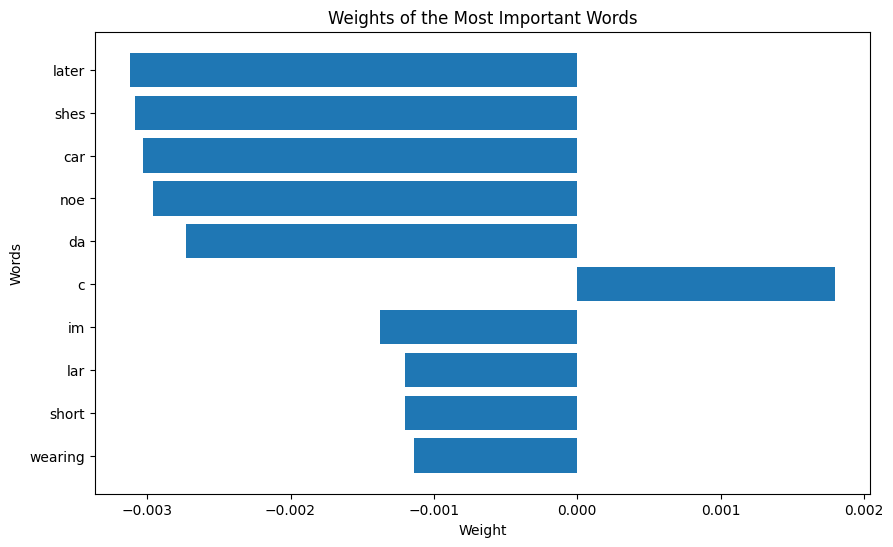

In [29]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Separar palavras e pesos em listas separadas
words = [word for word, weight in words_weights]
weights = [weight for word, weight in words_weights]

# Criar o gráfico de barras horizontais
plt.figure(figsize=(10, 6))  # Ajustar o tamanho da figura, se necessário
plt.barh(words, weights)
plt.xlabel("Weight")
plt.ylabel("Words")
plt.title("Weights of the Most Important Words")
plt.gca().invert_yaxis()  # Inverter o eixo y para que as palavras mais importantes estejam no topo
plt.show()

**Attention Viz**

In [30]:
le.classes_

array(['ham', 'spam'], dtype=object)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
A classe prevista para o texto é o índice: 0

Palavras do exemplo e seus pesos na decisão da classe prevista (LSTM):
      Feature    Weight
3157  measure  0.321858
837      park -0.132144


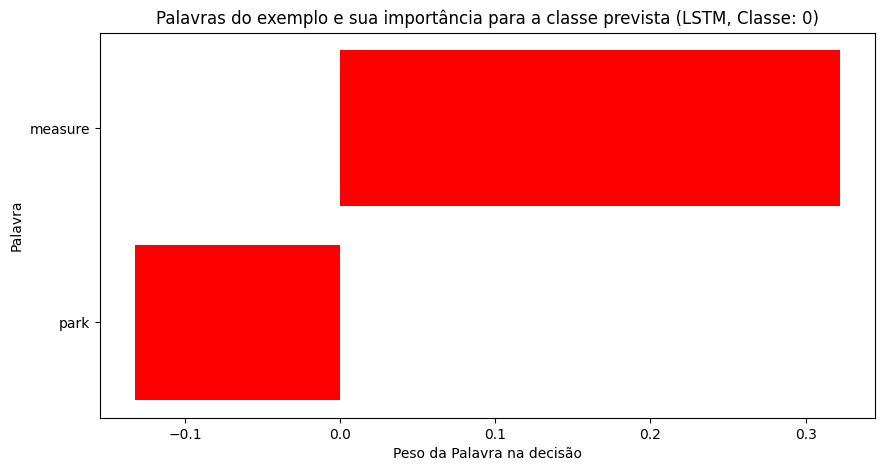

In [31]:
# Definir o texto de exemplo
sample_text = "preliminary estimation technology park measure square meter"

# **Etapa 1: Calcular a importância das palavras para cada classe do modelo LSTM**

# Obter os pesos da camada de Embedding
# Supondo que a camada de embedding é a primeira (índice 0)
embedding_weights = model.layers[0].get_weights()[0]

# Usar tokenizer.index_word para obter as palavras a partir dos índices
nomes_das_features = [tokenizer.index_word.get(i, '<OOV>') for i in range(1, embedding_weights.shape[0] + 1)]

# Obter os pesos da camada Dense (a última camada de saída)
dense_weights = model.layers[-1].get_weights()[0]

# Calcular a importância das palavras para cada classe
num_classes = dense_weights.shape[1]  # Número de classes de saída
importancias_das_features = []
for class_index in range(num_classes):
    # Obter os pesos da camada Dense para a classe atual
    class_weights = dense_weights[:, class_index]

    # Calcular a importância das palavras multiplicando os pesos da camada Dense pelos pesos da camada de Embedding
    word_importances = np.dot(embedding_weights, class_weights)

    importancias_da_classe = pd.DataFrame({'Feature': nomes_das_features, 'Weight': word_importances})
    importancias_da_classe = importancias_da_classe.sort_values(by='Weight', ascending=False)
    importancias_das_features.append(importancias_da_classe)

# **Etapa 2: Prever a classe do sample_text usando o modelo LSTM**

# O `maxlen` deve ser o mesmo usado durante o treinamento
# Assumindo que a variável `MAX_SEQUENCE_LENGTH` foi definida em uma célula anterior
# Caso contrário, defina-a aqui: MAX_SEQUENCE_LENGTH = ...
MAX_SEQUENCE_LENGTH = 100 # Substitua pelo valor correto do seu modelo

# Pré-processar o texto de exemplo para o modelo LSTM
sequence = tokenizer.texts_to_sequences([sample_text])
padded_sequence = pad_sequences(sequence, maxlen=MAX_SEQUENCE_LENGTH)

# Fazer a previsão
prediction = model.predict(padded_sequence)

# Obter o índice da classe prevista (a com maior probabilidade)
predicted_class_index = np.argmax(prediction[0])

print(f"A classe prevista para o texto é o índice: {predicted_class_index}")

# **Etapa 3: Visualizar a importância das palavras para a classe prevista**

# Selecionar o DataFrame de importâncias da classe prevista
importancias_da_classe_prevista = importancias_das_features[predicted_class_index]

# Criar um conjunto com as palavras do exemplo, para uma busca mais eficiente
# A regex `\b\w+\b` garante que apenas palavras sejam extraídas, ignorando pontuação
palavras_exemplo = set(re.findall(r'\b\w+\b', sample_text.lower()))

# Filtrar o DataFrame para incluir apenas as palavras que estão no texto de exemplo
importancias_exemplo_lstm = importancias_da_classe_prevista[
    importancias_da_classe_prevista['Feature'].apply(lambda x: x in palavras_exemplo)
]
importancias_exemplo_lstm = importancias_exemplo_lstm.sort_values(by='Weight', ascending=False)

# Exibir as importâncias das palavras do exemplo
print("\nPalavras do exemplo e seus pesos na decisão da classe prevista (LSTM):")
print(importancias_exemplo_lstm[['Feature', 'Weight']])

# **Etapa 4: Plotar o gráfico**

plt.figure(figsize=(10, 5))
plt.barh(importancias_exemplo_lstm['Feature'], importancias_exemplo_lstm['Weight'], color="red")
plt.xlabel("Peso da Palavra na decisão")
plt.ylabel("Palavra")
plt.title(f"Palavras do exemplo e sua importância para a classe prevista (LSTM, Classe: {predicted_class_index})")
plt.gca().invert_yaxis()
plt.show()

In [32]:
# Obter os pesos da camada de Embedding
embedding_weights = model.layers[0].get_weights()[0]  # A primeira camada é a Embedding

# Using tokenizer.index_word to get words from indices
nomes_das_features = [tokenizer.index_word.get(i, '<OOV>') for i in range(1, embedding_weights.shape[0] + 1)]

# Obter os pesos da camada Dense
dense_weights = model.layers[-1].get_weights()[0]  # A última camada é a Dense

# Calcular a importância das palavras para cada classe
num_classes = dense_weights.shape[1]  # Número de classes de saída
importancias_das_features = []
for class_index in range(num_classes):
    # Obter os pesos da camada Dense para a classe atual
    class_weights = dense_weights[:, class_index]

    # Calcular a importância das palavras multiplicando os pesos da camada Dense pelos pesos da camada de Embedding
    word_importances = np.dot(embedding_weights, class_weights)

    importancias_da_classe = pd.DataFrame({'Feature': nomes_das_features, 'Weight': word_importances})
    importancias_da_classe = importancias_da_classe.sort_values(by='Weight', ascending=False)
    importancias_das_features.append(importancias_da_classe)
# Exibir as importâncias das palavras para o mesmo exemplo usado no lime



In [33]:
class_index = 0
class_weights = dense_weights[:, class_index]
word_importances = np.dot(embedding_weights, class_weights)
importancias_negativas = pd.DataFrame({'Feature': nomes_das_features, 'Peso': word_importances})
importancias_negativas = importancias_negativas.sort_values(by='Peso', ascending=False)

print("Most important features for the Negative class:")
print(importancias_negativas.head(20))

Most important features for the Negative class:
        Feature      Peso
4223      magic  1.416444
1959       file  1.288781
1022       howz  1.037660
555      winner  0.823084
33        sorry  0.775572
334         til  0.740675
958     rowwjhl  0.711893
164        girl  0.707928
398       valid  0.699120
710          an  0.688529
891        save  0.669037
132         per  0.647763
959       sight  0.646628
3170       fifa  0.608284
1168         tt  0.607331
2120  contacted  0.606352
603        exam  0.597593
2636   reaction  0.594739
1441    putting  0.579199
249       guess  0.572593


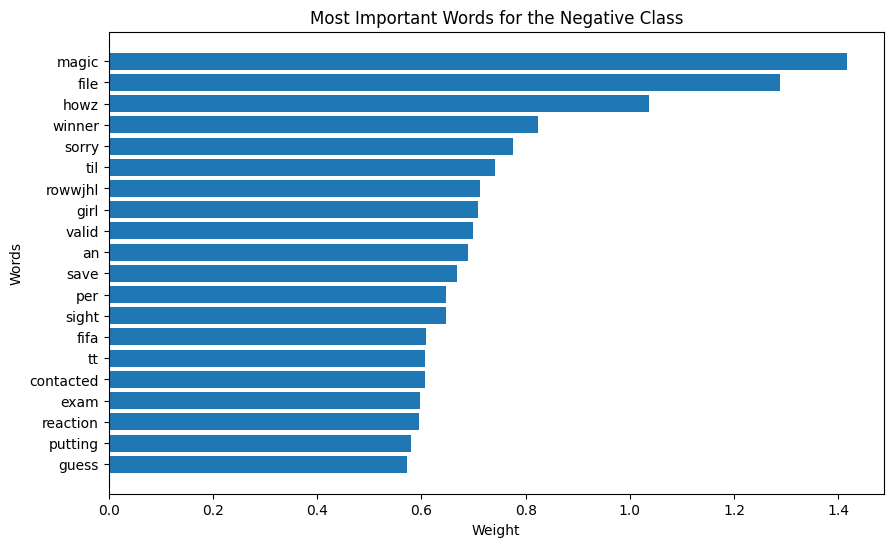

In [34]:
# Criar gráfico de barras para palavras negativas
plt.figure(figsize=(10, 6))
plt.barh(importancias_negativas['Feature'][:20], importancias_negativas['Peso'][:20])
plt.xlabel("Weight")
plt.ylabel("Words")
plt.title("Most Important Words for the Negative Class")
plt.gca().invert_yaxis()  # Inverter o eixo y para melhor visualização
plt.show()

In [35]:
class_index = 1
class_weights = dense_weights[:, class_index]
word_importances = np.dot(embedding_weights, class_weights)
importancias_neutras = pd.DataFrame({'Feature': nomes_das_features, 'Peso': word_importances})
importancias_neutras = importancias_neutras.sort_values(by='Peso', ascending=False)

print("Most important features for the Neutral class:")
print(importancias_neutras.head(20))

Most important features for the Neutral class:
         Feature      Peso
34         reply  1.029732
193          job  0.982129
284          jus  0.980980
2012        onto  0.969700
183          bit  0.944660
1696   holidayso  0.940093
336        thank  0.932008
2881    toughest  0.907342
1279        pack  0.883295
302          xxx  0.882591
195      holiday  0.881129
915       abiola  0.870393
72          hope  0.866308
282          den  0.855234
37         think  0.831273
390         pain  0.830242
513     everyone  0.828907
1641        recd  0.826363
4600  satsgettin  0.815100
1716   knackered  0.812688


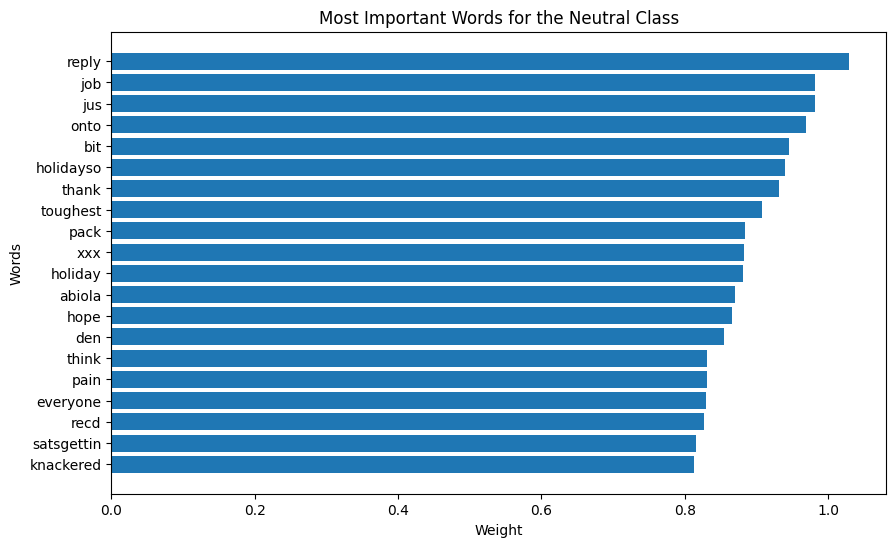

In [36]:
# Criar gráfico de barras para palavras neutras
plt.figure(figsize=(10, 6))
plt.barh(importancias_neutras['Feature'][:20], importancias_neutras['Peso'][:20])
plt.xlabel("Weight")
plt.ylabel("Words")
plt.title("Most Important Words for the Neutral Class")
plt.gca().invert_yaxis()  # Inverter o eixo y para melhor visualização
plt.show()

In [37]:
class_index = 2
class_weights = dense_weights[:, class_index]
word_importances = np.dot(embedding_weights, class_weights)
importancias_positivas = pd.DataFrame({'Feature': nomes_das_features, 'Peso': word_importances})
importancias_positivas = importancias_positivas.sort_values(by='Peso', ascending=False)

print("Most important features for the Positive class:")
print(importancias_positivas.head(20))

Most important features for the Positive class:
          Feature      Peso
0           <OOV>  0.802992
4146   correction  0.541725
4276       foward  0.533565
3406       opened  0.525313
1867        brain  0.510278
226         month  0.509662
1647        exact  0.495539
2012         onto  0.487721
1977      onwards  0.487028
535          club  0.483669
4828  gandhipuram  0.474322
1911       fuckin  0.468160
3428   antibiotic  0.463843
2266       jiayin  0.463467
1641         recd  0.461564
1716    knackered  0.457562
1720       chechi  0.457221
729            ha  0.454511
1036        bugis  0.453344
2827       wwwcom  0.450293


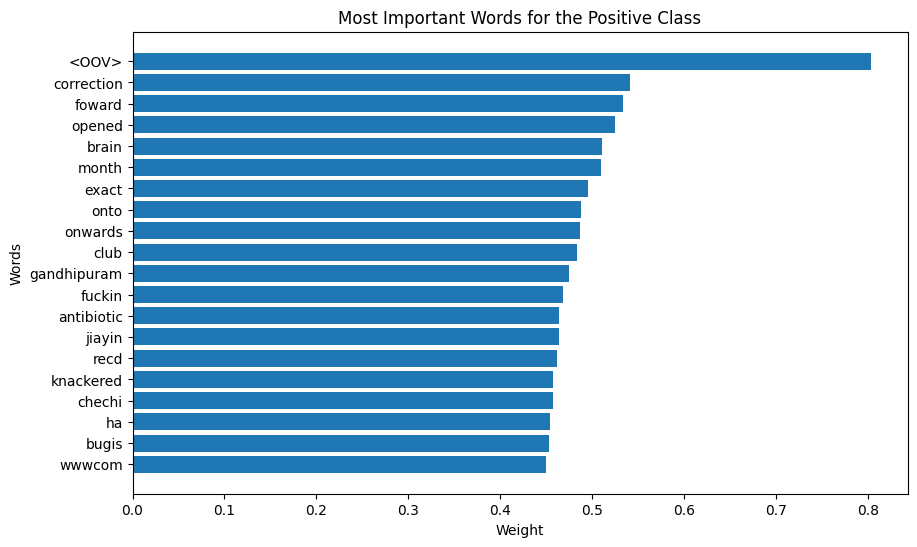

In [38]:
# Criar gráfico de barras para palavras positivas
plt.figure(figsize=(10, 6))
plt.barh(importancias_positivas['Feature'][:20], importancias_positivas['Peso'][:20])
plt.xlabel("Weight")
plt.ylabel("Words")
plt.title("Most Important Words for the Positive Class")
plt.gca().invert_yaxis()  # Inverter o eixo y para melhor visualização
plt.show()

Shapley

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
6575/6575 ━━━━━━━━━━━━━━━━━━━━ 641s 97ms/step


100%|██████████| 1/1 [12:22<00:00, 742.79s/it]


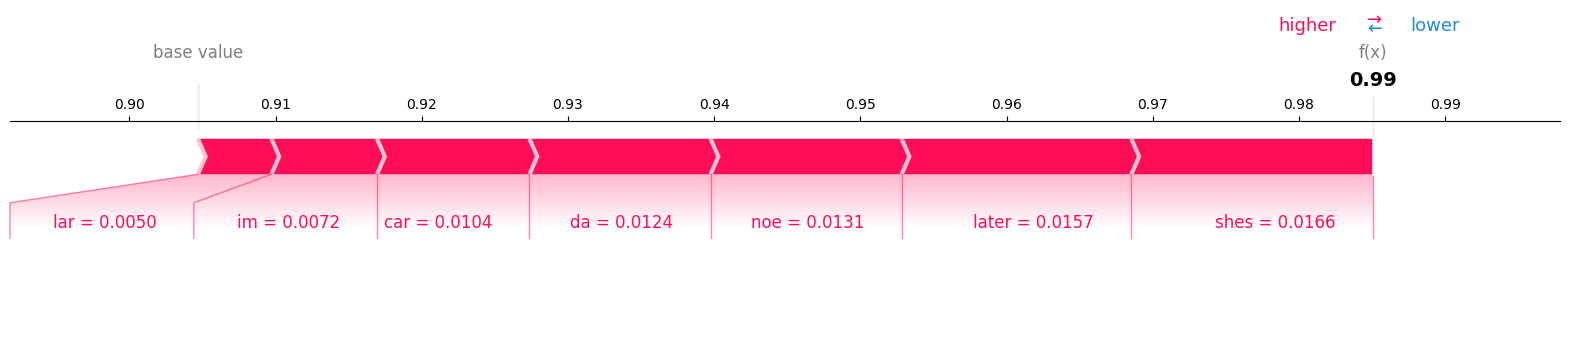

In [39]:
# =========================
# Definir índice da mesma instância usada no LIME
# =========================

lime_idx = 499

if lime_idx >= len(X_test_pad):
    raise ValueError("lime_idx fora do intervalo")

# Instância
X_instance = X_test_pad[lime_idx:lime_idx+1]

# =========================
# Descobrir classe predita automaticamente
# =========================

pred_probs = model.predict(X_instance)
pred_class_idx = np.argmax(pred_probs, axis=1)[0]

# =========================
# Criar função para explicar classe predita
# =========================

def predict_fn(x):
    preds = model.predict(x)
    return preds[:, pred_class_idx]

# =========================
# Criar background
# =========================

background_size = 100
background = X_train_pad[
    np.random.choice(
        X_train_pad.shape[0],
        min(background_size, X_train_pad.shape[0]),
        replace=False
    )
]

# =========================
# Criar explainer
# =========================

explainer = shap.KernelExplainer(predict_fn, background)

# =========================
# Calcular SHAP values
# =========================

shap_values = explainer.shap_values(X_instance)

shap_values = np.array(shap_values[0]).reshape(-1)

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = float(np.array(expected_value).reshape(-1)[0])

# =========================
# Converter tokens → palavras
# =========================

tokens = X_instance[0]

words = [
    tokenizer.index_word.get(int(token), "")
    for token in tokens
]

# =========================
# Remover PAD
# =========================

valid_indices = [i for i, w in enumerate(words) if w != ""]

words = [words[i] for i in valid_indices]
shap_values = shap_values[valid_indices]

# =========================
# Ordenar por impacto absoluto
# =========================

sorted_indices = np.argsort(np.abs(shap_values))[::-1]

top_k = 15
sorted_indices = sorted_indices[:top_k]

words = [words[i] for i in sorted_indices]
shap_values = shap_values[sorted_indices]

# =========================
# Criar labels formatados: [palavra = valor]
# =========================

# Criamos uma lista de strings combinando a palavra e o valor do SHAP formatado
formatted_labels = [
    f"{word} = {val:.4f}" 
    for word, val in zip(words, shap_values)
]

# =========================
# Force plot final com labels customizados
# =========================

shap.force_plot(
    expected_value, 
    shap_values, 
    feature_names=formatted_labels, # Usamos a lista formatada aqui
    matplotlib=True
)